### Business problem:
Road departments receive a large number of road-condition complaints and inspection reports. Manual inspection can be slow, expensive, and subjective. This project uses Computer Vision and Convolutional Neural Networks (CNN) to automatically classify road images into two categories: Clean Road and Potholes. The system can help authorities identify potentially damaged roads and prioritize inspection and maintenance.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_path = r"D:\CNN Project\Road_Condition_Dataset"

clean_path = os.path.join(dataset_path, "Clean road")
pothole_path = os.path.join(dataset_path, "Potholes")

print("Clean road images:", len(os.listdir(clean_path)))
print("Potholes images:", len(os.listdir(pothole_path)))

Clean road images: 370
Potholes images: 480


In [3]:
# Load images

# Lists to store images and their corresponding class names
row = []
labels = []

# We are using only these two classes
classes = ["Clean road", "Potholes"]

# Loop through every class folder in the dataset
for folder in classes:

    # Create the complete path of the class folder
    folder_path = os.path.join(dataset_path, folder)

    # Read every image in the folder
    for file_name in os.listdir(folder_path):

        # Create the complete path of the image
        image_path = os.path.join(folder_path, file_name)

        # Read the image using OpenCV
        image = cv2.imread(image_path)
        
        # Check whether the image was read successfully
        if image is None:
            print("Could not read:", image_path)
            continue

        # OpenCV reads images in BGR format. Convert BGR to RGB so that our image format is consistent.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize every image to the same dimensions
        # This is required because CNN models expect a consistent input image size.
        resized = cv2.resize(image, (120, 120))

        # Normalize pixel values from 0-255 to 0-1. This helps keep input values in a smaller range.
        resized = resized.astype("float32") / 255.0
        
        # Store the processed image in the image list
        row.append(resized)
        
        # Store the folder name as the image's class label
        labels.append(folder)

# Display the total number of images and labels
print("Total images:", len(row))
print("Total labels:", len(labels))

Total images: 850
Total labels: 850


In [4]:
# Check the shape of the first image
print("First image shape:", row[0].shape)

# Check the first image label
print("First image label:", labels[0])

First image shape: (120, 120, 3)
First image label: Clean road


### Check class distribution

In [5]:
from collections import Counter

class_counts = Counter(labels)

print("Class distribution:")
for class_name, count in class_counts.items():
    print(class_name, ":", count)

Class distribution:
Clean road : 370
Potholes : 480


#### Convert images into NumPy array

In [6]:
# Convert the list of processed images into a NumPy array
X = np.array(row)

# Display the shape of the complete image dataset
print("X shape:", X.shape)

X shape: (850, 120, 120, 3)


In [7]:
# Display dataset information
print("Total images:", len(X))
print("Total labels:", len(labels))
print("X shape:", X.shape)

# Display class distribution
from collections import Counter

class_counts = Counter(labels)

print("\nClass distribution:")

for class_name, count in class_counts.items():
    print(class_name, ":", count)

Total images: 850
Total labels: 850
X shape: (850, 120, 120, 3)

Class distribution:
Clean road : 370
Potholes : 480


### Encoding the 2 classes

In [8]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object. It converts text class names into numerical values.
encoder = LabelEncoder()

# Convert:
# Clean road -> 0
# Potholes   -> 1

# Convert the 2 text labels into numbers: 0, 1.
y = encoder.fit_transform(labels)

# Display the class names in their encoded order
print("Classes:", encoder.classes_)

# Display the mapping between class index and class name
for i, class_name in enumerate(encoder.classes_):
    print(i, ":", class_name)

Classes: ['Clean road' 'Potholes']
0 : Clean road
1 : Potholes


## Train/test split

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Split into 80% for training, 20% for testing data
# Training data is used to teach the CNN model.
# Testing data is used to evaluate the model on unseen images.

# random_state=21 ensures the same split every time we run the code.

# stratify=y maintains the class distribution as much as possible in both subsets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [11]:
# Display the shape of the training data
print("Training data:", X_train.shape, y_train.shape)

# Display the shape of the testing data
print("Testing data:", X_test.shape, y_test.shape)

Training data: (680, 120, 120, 3) (680,)
Testing data: (170, 120, 120, 3) (170,)


# Architecture

In [12]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [13]:
# Create a Sequential model. Sequential means layers are added one after another.

model = Sequential()

# Convolution Layer 1
# Extract basic visual features such as edges and simple textures from the input image.
model.add(Conv2D(32, (3,3), input_shape=(120,120,3), activation='relu'))
# Reduce the spatial size of feature maps. This decreases computation and retains important patterns.
model.add(MaxPool2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64,(3,3),activation='relu')) # Use more filters to learn additional visual patterns from the previous features.
model.add(MaxPool2D(pool_size=(2,2)))  # Reduce the feature map dimensions.

# Convolution Layer 3
model.add(Conv2D(128,(3,3),activation='relu')) # Extract deeper and more complex image features.
model.add(MaxPool2D(pool_size=(2,2)))  # Reduce the spatial dimensions again.

# FLATTEN LAYER - Convert the 2D feature maps into a one-dimensional vector for dense layers.
model.add(Flatten())

# FULLY CONNECTED LAYERS
model.add(Dense(128,activation='relu')) # Learn relationships between the extracted features.
model.add(Dropout(0.2)) # Randomly deactivate 20% of neurons during training to help reduce overfitting.

# Second dense layer
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2)) # Apply dropout again.

# Third dense layer
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2)) # Apply dropout again.

# OUTPUT LAYER
# We have only two classes. so we use 1 output neurons. Sigmoid gives a value between 0 and 1.
model.add(Dense(1, activation="sigmoid"))

# Display the model architecture
model.summary()

D:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 118, 118, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 59, 59, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 57, 57, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,769,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,872,641 (10.96 MB)

 Trainable params: 2,872,641 (10.96 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model before training.

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# binary_crossentropy is suitable for integer labels such as 0, 1.
# Accuracy measures how many predictions match the correct class labels.

In [15]:
# Train the CNN model using the training data.

history = model.fit(X_train, 
                    y_train, 
                    epochs=10, # Number of complete passes through the training data
                    batch_size=32, # Number of images processed in one batch
                    validation_data=(X_test, y_test) # Evaluate performance on testing data after each epoch
                   )

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 816ms/step - accuracy: 0.5515 - loss: 0.6932 - val_accuracy: 0.5647 - val_loss: 0.6734
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 899ms/step - accuracy: 0.6265 - loss: 0.6336 - val_accuracy: 0.8588 - val_loss: 0.4634
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8059 - loss: 0.4529 - val_accuracy: 0.8059 - val_loss: 0.4220
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 920ms/step - accuracy: 0.8691 - loss: 0.3405 - val_accuracy: 0.9118 - val_loss: 0.2473
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 969ms/step - accuracy: 0.8838 - loss: 0.2892 - val_accuracy: 0.9412 - val_loss: 0.2144
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 883ms/step - accuracy: 0.8956 - loss: 0.2712 - val_accuracy: 0.9118 - val_loss: 0.2094
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9309 - loss: 0.2043 - val_accuracy: 0.9588 - val_loss: 0.1280
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 879ms/step - accuracy: 0.9441 - loss: 0.1694 - val_accuracy: 

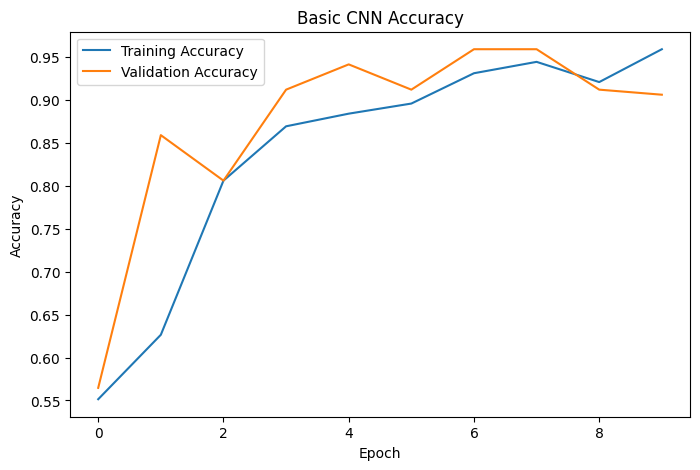

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN Accuracy")

plt.legend()
plt.show()

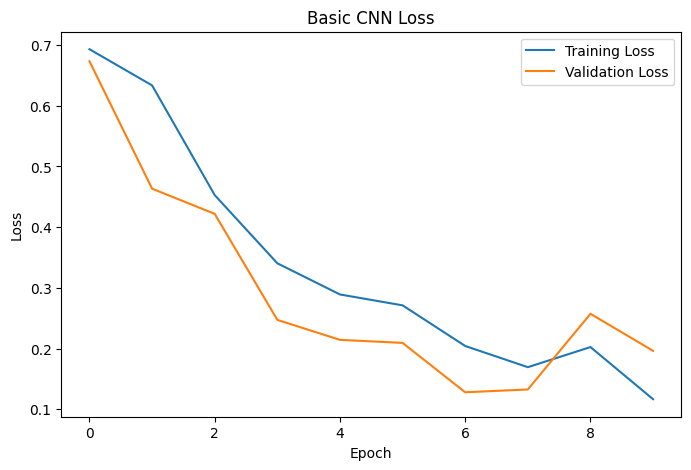

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN Loss")

plt.legend()
plt.show()

In [18]:
# Evaluate the trained model on the test dataset. This returns the loss and accuracy.

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

# Display the results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.9059 - loss: 0.1963
Test Loss: 0.19632059335708618
Test Accuracy: 0.9058823585510254


In [19]:
y_probability = model.predict(X_test, verbose=0)

In [20]:
# Convert probability into class
y_prediction = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

Predictions generated successfully!


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction, target_names=encoder.classes_))

              precision    recall  f1-score   support

  Clean road       0.84      0.97      0.90        74
    Potholes       0.98      0.85      0.91        96

    accuracy                           0.91       170
   macro avg       0.91      0.91      0.91       170
weighted avg       0.92      0.91      0.91       170



In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_prediction)
print(cm)

[[72  2]
 [14 82]]


In [23]:
model.save("road_damage_basic_cnn.keras")
np.save("road_damage_classes.npy", encoder.classes_)
print("Basic CNN and class names saved successfully!")

Basic CNN and class names saved successfully!


## Image prediction — automatic classes

In [24]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# We load the model that was trained on 5 road-condition classes.
model = load_model("road_damage_basic_cnn.keras")

# Load class names. This file contains the class names in the same order used by LabelEncoder during training.
classes = np.load("road_damage_classes.npy", allow_pickle=True)
print("Available classes:", classes)

# Change this path to any image you want to test.
image_path = r"D:\CNN Project\Road_Condition_Dataset\Potholes\Potholes 1 (5).jpg"

# OpenCV reads images in BGR format.
image = cv2.imread(image_path)

# Check if the image was loaded successfully.
if image is None:
    print("Could not read the image:", image_path)
    raise SystemExit

# Resize the image. The CNN expects an image size of 120 x 120 x 3.
resized = cv2.resize(image, (120, 120))

# Normalize pixel values
# During training, images were divided by 255. We apply the same normalization during prediction.
resized = resized.astype("float32") / 255.0

# Add batch dimension
# A single image must be provided as a batch of 1 image. Shape becomes: (1, 120, 120, 3)
test_input = np.expand_dims(resized, axis=0)

print("Input shape:", test_input.shape)

# Predict the road condition. The model returns 2 output probabilities.
probability = model.predict(test_input, verbose=0)[0][0]

# Convert probability to class
if probability >= 0.5:
    predicted_class = 1
else:
    predicted_class = 0
    
# Convert the class index into its actual name.
predicted_label = classes[predicted_class]

# Calculate confidence
if predicted_class == 1:
    confidence = probability
else:
    confidence = 1 - probability

print("--------------------------------------")
print("Predicted Road Condition:", predicted_label)
print("Confidence:", round(float(confidence*100), 2), "%")

Available classes: ['Clean road' 'Potholes']
Input shape: (1, 120, 120, 3)
--------------------------------------
Predicted Road Condition: Potholes
Confidence: 99.83 %


# Data Augumentation

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [26]:
# Create the augmentation pipeline
# We generate slightly modified training images so the CNN sees more visual variations.

datagen = ImageDataGenerator(
    rotation_range=20, # Rotate images randomly. This helps the model handle different camera angles.
    width_shift_range=0.15, # Move image horizontally.
    height_shift_range=0.15, # Move image vertically.
    zoom_range=0.15, # Zoom in/out slightly.
    shear_range=0.15, # Slightly distort the image.
    horizontal_flip=True, # Flip image horizontally.
    fill_mode='nearest'  # fill the newly generated pixels values with near pixels
)

### Create training generator

In [27]:
# Create an augmented training data generator. It generates transformed images in batches during training.

train_generator = datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

In [28]:
# Create a fresh CNN model with data augmentation

model_aug = Sequential()

# Convolution Layer 1
# Feature extraction
model_aug.add(Conv2D(32, (3, 3), input_shape=(120, 120, 3), activation='relu'))

# Max Pooling Layer 1
model_aug.add(MaxPool2D(pool_size=(2, 2)))

# Convolution Layer 2
model_aug.add(Conv2D(64, (3, 3), activation='relu'))

# Max Pooling Layer 2
model_aug.add(MaxPool2D(pool_size=(2, 2)))

# Convolution Layer 3
model_aug.add(Conv2D(128, (3, 3), activation='relu'))

# Max Pooling Layer 3
model_aug.add(MaxPool2D(pool_size=(2, 2)))

# Convert feature maps into one-dimensional vector
model_aug.add(Flatten())

# Fully Connected Layer 1
model_aug.add(Dense(128, activation='relu'))
model_aug.add(Dropout(0.2))

# Fully Connected Layer 2
model_aug.add(Dense(64, activation='relu'))
model_aug.add(Dropout(0.2))

# Fully Connected Layer 3
model_aug.add(Dense(32, activation='relu'))
model_aug.add(Dropout(0.2))

# Final Output Layer 2 road condition classes
# Binary classification
model_aug.add(Dense(1, activation="sigmoid"))

model_aug.summary()

D:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 118, 118, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 59, 59, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 57, 57, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 26, 26, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 13, 13, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       2,769,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,872,641 (10.96 MB)

 Trainable params: 2,872,641 (10.96 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
# Train CNN using augmented training images

history_aug = model_aug.fit(train_generator, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 989ms/step - accuracy: 0.5426 - loss: 0.6942 - val_accuracy: 0.8706 - val_loss: 0.6265
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7132 - loss: 0.5749 - val_accuracy: 0.8824 - val_loss: 0.3464
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8221 - loss: 0.4046 - val_accuracy: 0.8824 - val_loss: 0.2878
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8706 - loss: 0.3691 - val_accuracy: 0.8235 - val_loss: 0.4411
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8765 - loss: 0.3433 - val_accuracy: 0.8235 - val_loss: 0.4647
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8618 - loss: 0.3658 - val_accuracy: 0.8353 - val_loss: 0.4953
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 935ms/step - accuracy: 0.8574 - loss: 0.3664 - val_accuracy: 0.9000 - val_loss: 0.2313
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 949ms/step - accuracy: 0.8765 - loss: 0.3194 - val_accuracy: 0.8176 - 

In [31]:
# Evaluate the model on the test images. X_test contains images that were not used in the training batches.
# This gives us the test loss and test accuracy.

test_loss_aug, test_accuracy_aug = model_aug.evaluate(X_test, y_test, verbose=1)

print("Augmented CNN Test Loss:", test_loss_aug)
print("Augmented CNN Test Accuracy:", test_accuracy_aug)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.8529 - loss: 0.3566
Augmented CNN Test Loss: 0.3566020429134369
Augmented CNN Test Accuracy: 0.8529411554336548


In [32]:
print("Basic CNN Accuracy:", round(test_accuracy * 100, 2), "%")
print("Augmented CNN Accuracy:", round(test_accuracy_aug * 100, 2), "%")

Basic CNN Accuracy: 90.59 %
Augmented CNN Accuracy: 85.29 %


In [33]:
# Predict probabilities for every test image.

y_probability_aug = model_aug.predict(X_test, verbose=0)

# Select the class with the highest probability. axis=1 means we select the highest value across the 2 output classes.
y_prediction_aug = (y_probability_aug >= 0.5).astype(int).flatten()

In [34]:
print(classification_report(y_test, y_prediction_aug, target_names=encoder.classes_))

              precision    recall  f1-score   support

  Clean road       0.96      0.69      0.80        74
    Potholes       0.80      0.98      0.88        96

    accuracy                           0.85       170
   macro avg       0.88      0.83      0.84       170
weighted avg       0.87      0.85      0.85       170



In [35]:
model_aug.save("road_damage_with_augmentation.keras")
print("Augmented CNN saved successfully!")

Augmented CNN saved successfully!


## VGG16 Transfer Learning

VGG16 is a pretrained CNN that has already learned general image features such as:

* Edges
* Shapes
* Textures
* Patterns

Instead of training everything from the beginning, we reuse these learned features and add our own classification layers for the five road conditions.

VGG16 has already learned general visual features from ImageNet.

Instead of learning everything from zero:

Our images
    
    ↓

VGG16 pretrained features

    ↓

Our road classification layer

In [36]:
# PREPARE DATA FOR VGG16

from tensorflow.keras.applications import VGG16

In [37]:
pre_trained_vgg = VGG16(include_top=False, weights="imagenet", input_shape=(120, 120, 3))
pre_trained_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 120, 120, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 120, 120, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 60, 60, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 30, 30, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 30, 30, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 7, 7, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Freeze VGG16

Initially we don't want to modify the pretrained VGG16 features.

We only train our new classification layers.

In [38]:
pre_trained_vgg.trainable = False

### Create VGG16 road model

In [39]:
vgg_model = Sequential()

# Pretrained VGG16 feature extractor
vgg_model.add(pre_trained_vgg)

# Convert feature maps into a vector
vgg_model.add(Flatten())

# Our own classification layers
vgg_model.add(Dense(128, activation="relu"))
vgg_model.add(Dropout(0.3))

vgg_model.add(Dense(64, activation="relu"))

# Two classes -> one sigmoid output
vgg_model.add(Dense(1, activation="sigmoid"))

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 3, 3, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,312,961 (58.41 MB)

 Trainable params: 598,273 (2.28 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
# Compile VGG16 model

vgg_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [41]:
from tensorflow.keras.applications.vgg16 import preprocess_input

X_train_vgg = preprocess_input(X_train * 255.0)
X_test_vgg = preprocess_input(X_test * 255.0)

print(X_train_vgg.shape)
print(X_test_vgg.shape)

(680, 120, 120, 3)
(170, 120, 120, 3)


In [42]:
# Train VGG16

history_vgg = vgg_model.fit(X_train_vgg, y_train, epochs=5, batch_size=32, validation_data=(X_test_vgg, y_test))

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 198s 9s/step - accuracy: 0.8735 - loss: 0.7480 - val_accuracy: 0.9353 - val_loss: 0.3287
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 191s 9s/step - accuracy: 0.9676 - loss: 0.1352 - val_accuracy: 0.9471 - val_loss: 0.2539
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 173s 7s/step - accuracy: 0.9838 - loss: 0.0475 - val_accuracy: 0.9529 - val_loss: 0.2233
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 226s 9s/step - accuracy: 0.9897 - loss: 0.0512 - val_accuracy: 0.9588 - val_loss: 0.3113
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 184s 8s/step - accuracy: 0.9838 - loss: 0.0736 - val_accuracy: 0.9647 - val_loss: 0.5441


In [43]:
# Evaluate VGG16

vgg_loss, vgg_accuracy = vgg_model.evaluate(X_test_vgg, y_test, verbose=1)
print("VGG16 Test Accuracy:", round(vgg_accuracy * 100, 2), "%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 6s/step - accuracy: 0.9647 - loss: 0.5441
VGG16 Test Accuracy: 96.47 %


### Compare all models

In [44]:
print("MODEL COMPARISON")

print("Basic CNN:", round(test_accuracy * 100, 2))

print("CNN + Augmentation:", round(test_accuracy_aug * 100, 2))

print("VGG16 Transfer Learning:", round(vgg_accuracy * 100, 2))

MODEL COMPARISON
Basic CNN: 90.59
CNN + Augmentation: 85.29
VGG16 Transfer Learning: 96.47


### Fine-tuning VGG16

In [45]:
# First freeze everything

pre_trained_vgg.trainable = True

for layer in pre_trained_vgg.layers:
    layer.trainable = False

In [46]:
# Now unfreeze only the last convolutional block

for layer in pre_trained_vgg.layers:

    if layer.name.startswith("block5"):
        layer.trainable = True

In [47]:
for layer in pre_trained_vgg.layers:
    print(layer.name, layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


### Recompile with small learning rate

In [48]:
from tensorflow.keras.optimizers import RMSprop

vgg_model.compile(optimizer=RMSprop(learning_rate=1e-5), loss="binary_crossentropy", metrics=["accuracy"])

### Fine-tune

In [49]:
history_finetune = vgg_model.fit(
    X_train_vgg,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_vgg, y_test)
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 197s 9s/step - accuracy: 0.9985 - loss: 0.0024 - val_accuracy: 0.9882 - val_loss: 0.4211
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 271s 12s/step - accuracy: 0.9941 - loss: 0.0388 - val_accuracy: 0.9824 - val_loss: 0.3742
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 175s 5s/step - accuracy: 0.9985 - loss: 0.0029 - val_accuracy: 0.9882 - val_loss: 0.3826
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.9985 - loss: 0.0039 - val_accuracy: 0.9882 - val_loss: 0.3472
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9985 - loss: 0.0035 - val_accuracy: 0.9882 - val_loss: 0.3645


In [50]:
# Evaluate fine-tuned model

fine_loss, fine_accuracy = vgg_model.evaluate(X_test_vgg, y_test, verbose=1)

print("Fine-tuned VGG16 Accuracy:", round(fine_accuracy * 100, 2), "%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9882 - loss: 0.3645    
Fine-tuned VGG16 Accuracy: 98.82 %


In [51]:
# Save final model

vgg_model.save("road_damage_vgg16_final.keras")

np.save("road_damage_classes.npy", encoder.classes_)

print("Final model saved successfully!")

Final model saved successfully!


### Final image prediction

In [52]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load final model
final_model = load_model("road_damage_vgg16_final.keras")

# Load class names
classes = np.load("road_damage_classes.npy", allow_pickle=True)

# Give a new road image
image_path = r"D:\CNN Project\Road_Condition_Dataset\Potholes\Potholes 1 (6).jpg"

# Read image
image = cv2.imread(image_path)

if image is None:
    print("Could not read image")
    raise SystemExit

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize
resized = cv2.resize(image, (120, 120))

# Normalize
# resized = resized.astype("float32") / 255.0

resized = resized.astype("float32")
resized = preprocess_input(resized)

# Add batch dimension
test_input = np.expand_dims(resized, axis=0)

# Prediction
probability = final_model.predict(test_input, verbose=0)[0][0]

# Convert probability to class
if probability >= 0.5:
    predicted_class = 1
else:
    predicted_class = 0

predicted_label = classes[predicted_class]

# Calculate confidence
if predicted_class == 1:
    confidence = probability
else:
    confidence = 1 - probability

print("--------------------------------")
print("Predicted Road Condition:", predicted_label)
print("Confidence:", round(float(confidence * 100), 2), "%")
print("--------------------------------")

--------------------------------
Predicted Road Condition: Potholes
Confidence: 100.0 %
--------------------------------


## Video prediction

In [ ]:
import cv2
import numpy as np

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input


# ---------------------------------------------------------
# 1. Load trained VGG16 model
# ---------------------------------------------------------

model = load_model("road_damage_vgg16_final.keras")


# ---------------------------------------------------------
# 2. Load class names
# ---------------------------------------------------------

classes = np.load(
    "road_damage_classes.npy",
    allow_pickle=True
)

print("Classes:", classes)


# ---------------------------------------------------------
# 3. Input and output video paths
# ---------------------------------------------------------

video_path = r"D:\CNN Project\vidssave.com Data Annotation For Road Pothole Detection _ Wisepl _ Machine Learning _ Computer Vision _ AI 720P.mp4"

output_path = r"D:\CNN Project\road_condition_output.mp4"


# ---------------------------------------------------------
# 4. Open input video
# ---------------------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Could not open input video")
    raise SystemExit


# ---------------------------------------------------------
# 5. Get video properties
# ---------------------------------------------------------

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)


print("Video width:", width)
print("Video height:", height)
print("FPS:", fps)


# ---------------------------------------------------------
# 6. Create output video writer
# ---------------------------------------------------------

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)


# ---------------------------------------------------------
# 7. Process video frame by frame
# ---------------------------------------------------------

while True:

    # Read one frame
    ret, frame = cap.read()

    # Stop when video ends
    if not ret:
        break


    # -----------------------------------------------------
    # 8. Convert BGR -> RGB
    # -----------------------------------------------------

    rgb_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )


    # -----------------------------------------------------
    # 9. Resize frame for VGG16
    # -----------------------------------------------------

    resized = cv2.resize(
        rgb_frame,
        (120, 120)
    )


    # -----------------------------------------------------
    # 10. Apply SAME preprocessing used during training
    # -----------------------------------------------------

    resized = resized.astype("float32")

    processed = preprocess_input(resized)


    # -----------------------------------------------------
    # 11. Add batch dimension
    # -----------------------------------------------------

    input_image = np.expand_dims(
        processed,
        axis=0
    )


    # -----------------------------------------------------
    # 12. Predict road condition
    # -----------------------------------------------------

    probability = model.predict(
        input_image,
        verbose=0
    )[0][0]


    # -----------------------------------------------------
    # 13. Convert probability to class
    # -----------------------------------------------------

    if probability >= 0.5:

        predicted_class = 1
        confidence = probability
        label = "POTHOLES"

    else:

        predicted_class = 0
        confidence = 1 - probability
        label = "CLEAN ROAD"


    # -----------------------------------------------------
    # 14. Create text
    # -----------------------------------------------------

    text = (
        f"{label} | "
        f"Confidence: {confidence * 100:.2f}%"
    )


    # -----------------------------------------------------
    # 15. Add prediction to video frame
    # -----------------------------------------------------

    cv2.putText(
        frame,
        text,
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255) if predicted_class == 1 else (0, 255, 0),
        2
    )


    # -----------------------------------------------------
    # 16. Save processed frame
    # -----------------------------------------------------

    out.write(frame)


# ---------------------------------------------------------
# 17. Release resources
# ---------------------------------------------------------

cap.release()
out.release()
cv2.destroyAllWindows()

print("Video processing completed.")
print("Output saved at:")
print(output_path)

Classes: ['Clean road' 'Potholes']
Video width: 1280
Video height: 720
FPS: 25.0
